# Experiment 3 : EGFR Activity

**Drug Modeled:** Gefitinib

**Condition Tested:** Relative EGFR activity in diffusion region

**Research Question:** How does gefitinib concentration affect EGFR activity?

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Generating logarithmic list of getfitinib concentration values (a.u.)
C = np.logspace(-5, 0, 100, base=10)

# Hill coefficient
n = 1

# IC50 value (a.u.), represents the gefitinib concentration to induce 50% inhibition of epidermal growth factor receptor kinases (EGFR)
ic_50 = 0.3

# Defining activity function using concentration values
A = 1 / (1 + (C / ic_50) ** n)

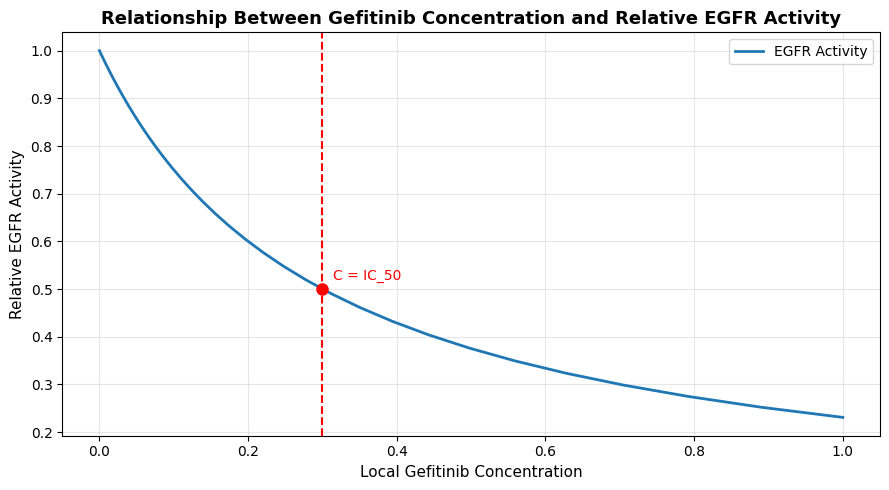

In [115]:
# Plot

fig, ax = plt.subplots(figsize = (9,5))

ax.plot(C, A, linewidth = 2, label = 'EGFR Activity')

# Labels and formatting
ax.set_title('Relationship Between Gefitinib Concentration and Relative EGFR Activity', 
                fontsize = 13, fontweight = 'bold')


ax.set_xlabel('Local Gefitinib Concentration', fontsize = 11)

ax.set_ylabel('Relative EGFR Activity', fontsize = 11)

ax.axvline(ic_50, linestyle = '--', color = 'red')

ax.annotate('C = IC_50', xy=(0.360,0.520), fontsize=10, ha='center', color='red')

ax.plot(ic_50, 0.5, 'o', markersize=8, color='red')

ax.legend(fontsize = 10)
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.savefig('figures/exp03_EGFR_activity_baseline.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Figure 3A

**Figure 3A.** Simulated relationship between local gefitinib concentration and normalized EGFR activity using the Hill inhibition model. EGFR activity decreases nonlinearly as drug concentration increases, with the $IC_{50}$ corresponding to the concentration producing 50% inhibition.

### Observations

* Non-linear decrease of EGFR activity as gefitinib concentration linearly increases
* At vessel normalized concentration, EGFR activity is not absolutely zero
* If it follows the exponential curve, will become asymptotal as gefitinib concentration increases

### Interpretation

The Hill model demonstrates that EGFR inhibition exhibits a nonlinear, saturating response rather than a proportional relationship with drug concentration. Consequently, equivalent increases in gefitinib concentration do not produce equivalent reductions in receptor activity across the concentration range. Sensitivity to concentration changes is greatest near the $IC_{50}$, where relatively small differences in local drug availability produce the largest changes in receptor inhibition.

### Discussion

This nonlinear concentration–response relationship has important implications for spatial drug delivery. Concentration differences generated through heterogeneous diffusion may be modest in absolute magnitude but can translate into substantially different levels of EGFR inhibition if they occur near the steep portion of the Hill curve. Conversely, regions with concentrations well above the $IC_{50}$ experience diminishing returns, as receptor inhibition approaches saturation. These findings indicate that the biological consequences of spatial drug gradients depend not only on transport but also on the intrinsic pharmacodynamics of EGFR inhibition.

In [116]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Generating logarithmic list of getfitinib concentration values (a.u.)
C = np.logspace(-5, 0, 100, base=10)

# Various hill coefficients
hill_coeffs = [1, 2, 4]

# IC50 value (a.u.), represents the gefitinib concentration to induce 50% inhibition of epidermal growth factor receptor kinases (EGFR)
ic_50 = 0.3

# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

In [117]:
# EGFR Activity Solutions

activity_profiles_1 = []

for h in hill_coeffs:
    # Current activity profile
    A = 1 / (1 + (C / ic_50) ** h)

    # Append current profile to array
    activity_profiles_1.append(A)

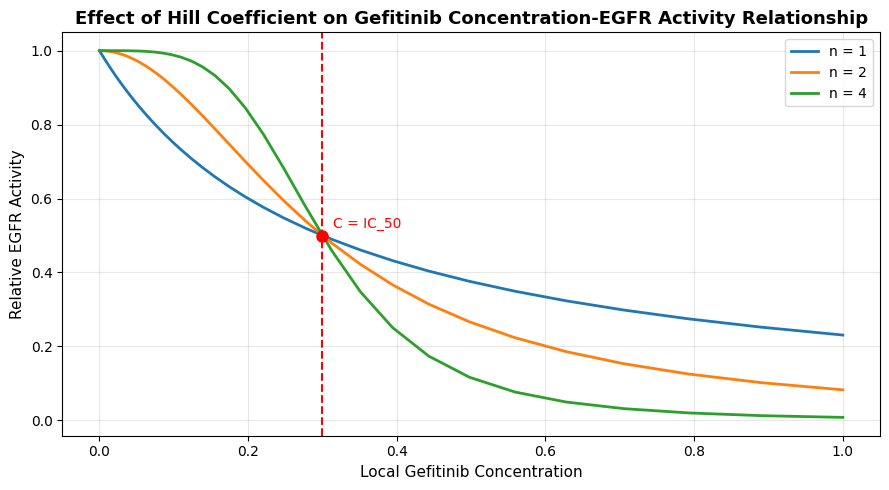

In [118]:
# Plot

fig, ax = plt.subplots(figsize=(9, 5))

for i, (A, n) in enumerate(zip(activity_profiles_1, hill_coeffs)):
    ax.plot(C, A, color=colors[i],
                linewidth=2, label=f'n = {n}')
    
# Labels and formatting

ax.set_title('Effect of Hill Coefficient on Gefitinib Concentration-EGFR Activity Relationship', fontsize=13, fontweight='bold')

ax.set_xlabel('Local Gefitinib Concentration', fontsize=11)

ax.set_ylabel('Relative EGFR Activity', fontsize=11)

ax.axvline(ic_50, linestyle = '--', color = 'red')

ax.annotate('C = IC_50', xy=(0.360,0.520), fontsize=10, ha='center', color='red')

ax.plot(ic_50, 0.5, 'o', markersize=8, color='red')

ax.legend(fontsize = 10)
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.savefig('figures/exp03_hill_variation.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## Figure 3B

**Figure 3B.** Influence of the Hill coefficient on the simulated gefitinib concentration–EGFR activity relationship. Increasing the Hill coefficient produces a steeper transition between active and inhibited receptor states.

### Observations

* As the Hill coefficient increases, the inhibition curve steepens
* Concavity between n=1 and n=4 cases are drastically different
* Midway 50% inhibition point (C = IC_50) is consistent, graph behavior on both sides differs
* Lower values, gradual decrease
* Higher values, switch-like response

### Interpretation

The Hill coefficient governs the sensitivity of EGFR activity to local changes in gefitinib concentration. Higher values compress the transition region, meaning that small spatial differences in concentration produce much larger differences in receptor inhibition.

### Discussion

Variation in the Hill coefficient illustrates how pharmacodynamic sensitivity can amplify spatial heterogeneity. Even if drug transport is unchanged, tissues with steeper concentration–response behavior may exhibit more pronounced biological variability. This emphasizes that therapeutic heterogeneity arises from the combined effects of drug distribution and receptor pharmacodynamics rather than transport alone.

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Generating logarithmic list of gefitinib concentration values (a.u.)
C = np.logspace(-5, 0, 100, base=10)

# Hill coefficient
n = 1

# Various IC_50 values (a.u.)
ic_50_values = [0.05, 0.15, 0.3, 0.6, 0.9]

# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', "#da371b", "#9e60cd"]

In [120]:
# EGFR Activity Solutions

activity_profiles_2 = []

for i in ic_50_values:
    # Current activity profile
    A = 1 / (1 + (C / i) ** n)

    # Append profile to array
    activity_profiles_2.append(A)

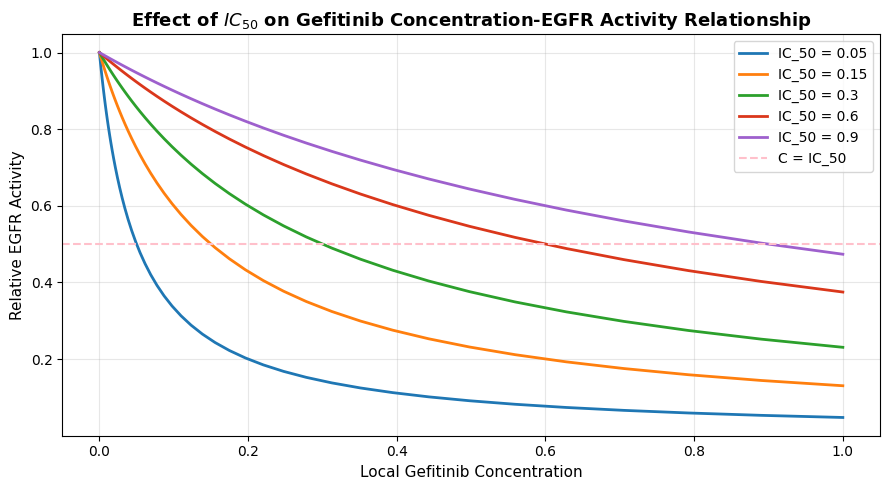

In [121]:
# Plot

fig, ax = plt.subplots(figsize=(9,5))

for i, (A, c_50) in enumerate(zip(activity_profiles_2, ic_50_values)):
    ax.plot(C, A, color=colors[i],
                linewidth=2, label=f'IC_50 = {c_50}')
    
# Labels and formatting

ax.set_title('Effect of $IC_{50}$ on Gefitinib Concentration-EGFR Activity Relationship', fontsize=13, fontweight='bold')

ax.set_xlabel('Local Gefitinib Concentration', fontsize=11)

ax.set_ylabel('Relative EGFR Activity', fontsize=11)

ax.axhline(0.5, linestyle = '--', color = 'pink', label='C = IC_50')

ax.legend(fontsize = 10)
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.savefig('figures/exp03_ic_50_variation.png', dpi = 150, bbox_inches = 'tight')
plt.show()


## Figure 3C

**Figure 3C.** Simulated EGFR inhibition curves for different $IC_{50}$ values representing varying cellular sensitivity to gefitinib. Lower $IC_{50}$ values indicate greater drug sensitivity, whereas higher values correspond to reduced sensitivity.

### Observations

* Increasing the $IC_{50}$ shifts the inhibition curve toward higher drug concentrations
* Cells with lower $IC_{50}$ achieve comparable levels of EGFR inhibition at substantially lower gefitinib concentrations
* Halfway inhibition point ($C = IC_{50}$) shifts for each curve

### Interpretation

The $IC_{50}$ determines the concentration range over which EGFR inhibition occurs. Higher values require greater local drug exposure to achieve equivalent receptor suppression, effectively reducing drug sensitivity.

### Discussion

Differences in $IC_{50}$ provide a simplified representation of variability in therapeutic response, such as intrinsic differences in drug sensitivity or changes associated with acquired resistance. Although this study focuses on L858R-mutant NSCLC, examining a range of plausible $IC_{50}$ values demonstrates how pharmacodynamic parameters influence the translation of spatial drug gradients into biological response. This analysis also establishes the foundation for the sensitivity analysis performed later, where $IC_{50}$ is evaluated alongside transport parameters as a potential driver of proliferation heterogeneity.